In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# =========================
# EDIT THIS CELL FIRST
# =========================

# Folder containing the daily pickle files
DATA_PATH = r"C:\Users\USER\Documents\GitHub\datasets\simbarca\all_agg"

# Key inside each pickle dict
PICKLE_KEY = "pred_vtime"

# We only care about this time of day
TARGET_TIME = "09:00:00"

# If a file does not contain TARGET_TIME:
# - False -> raise an error immediately
# - True  -> skip that file
SKIP_FILES_WITHOUT_TARGET_TIME = False

# Split by day
USE_EXPLICIT_SPLIT = False
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15   # test gets the rest

# Optional explicit split by number of days instead
TRAIN_DAYS = None
VAL_DAYS = None

# Historical mean baseline
HISTORY_DAYS = 20

# Metrics normalization
USE_MEAN_ABS_NORMALIZATION = True

# Drop columns that are NaN for every day
DROP_ALL_NAN_COLUMNS = True

In [3]:
def load_one_pickle_dataframe(file_path, pickle_key):
    """
    Load a single pickle file and return the DataFrame stored at pickle_key.
    """
    with open(file_path, "rb") as f:
        obj = pickle.load(f)

    if isinstance(obj, pd.DataFrame):
        df = obj

    elif isinstance(obj, dict):
        if pickle_key not in obj:
            raise KeyError(
                f"Key '{pickle_key}' not found in {file_path}. "
                f"Available keys: {list(obj.keys())}"
            )
        df = obj[pickle_key]

    else:
        raise TypeError(
            f"Unsupported pickle content in {file_path}: {type(obj)}"
        )

    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Loaded object from {file_path} is not a DataFrame.")

    # Make values numeric
    df = df.apply(pd.to_numeric, errors="coerce")

    return df


def extract_row_at_target_time(df_day, target_time="09:00:00"):
    """
    Extract exactly one row corresponding to target_time from a daily dataframe.

    Works whether the index is:
    - DatetimeIndex
    - strings
    - time-like objects
    """
    raw_index = pd.Index(df_day.index)
    raw_str = pd.Series(raw_index.astype(str))

    # Attempt to parse as datetime and compare HH:MM:SS
    parsed = pd.to_datetime(raw_str, errors="coerce")
    parsed_hms = parsed.dt.strftime("%H:%M:%S").fillna("")

    # Match either directly or through parsed time
    mask = (raw_str == target_time) | (parsed_hms == target_time)

    if mask.sum() == 0:
        raise ValueError(f"Target time {target_time} not found in this file.")

    # If multiple matches exist, keep the first one
    row = df_day.loc[mask.values].iloc[0]

    return row


def load_daily_0900_dataframe(folder_path, pickle_key, target_time="09:00:00",
                              skip_missing=False):
    """
    Build a dataframe with one row per file/day, using only the row at TARGET_TIME.

    Output:
    - rows    = days
    - columns = node ids
    """
    if not os.path.isdir(folder_path):
        raise ValueError(f"DATA_PATH is not a folder: {folder_path}")

    pickle_files = sorted([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if os.path.isfile(os.path.join(folder_path, f))
        and os.path.splitext(f)[1].lower() in [".pkl", ".pickle"]
    ])

    if len(pickle_files) == 0:
        raise ValueError(f"No pickle files found in folder: {folder_path}")

    print(f"Found {len(pickle_files)} pickle files.")

    rows = []
    filenames_used = []
    skipped_files = []

    for i, file_path in enumerate(pickle_files, 1):
        try:
            df_day = load_one_pickle_dataframe(file_path, pickle_key=pickle_key)
            row_0900 = extract_row_at_target_time(df_day, target_time=target_time)

            rows.append(row_0900)
            filenames_used.append(os.path.basename(file_path))

            if i <= 3 or i == len(pickle_files):
                print(f"[{i}/{len(pickle_files)}] Loaded {os.path.basename(file_path)}")

        except Exception as e:
            if skip_missing:
                skipped_files.append((os.path.basename(file_path), str(e)))
                continue
            else:
                raise RuntimeError(
                    f"Failed while processing file: {file_path}\nReason: {e}"
                )

    if len(rows) == 0:
        raise ValueError("No daily rows were loaded successfully.")

    # One row per day
    df_daily = pd.DataFrame(rows)

    # Give it a synthetic daily DatetimeIndex
    # This keeps the notebook simple even if filenames do not contain dates.
    df_daily.index = pd.date_range(
        start="2000-01-01",
        periods=len(df_daily),
        freq="D"
    )
    df_daily.index.name = "day"

    # Store filename mapping separately
    file_map = pd.DataFrame({
        "day_index": df_daily.index,
        "source_file": filenames_used
    })

    if DROP_ALL_NAN_COLUMNS:
        df_daily = df_daily.dropna(axis=1, how="all")

    print("\nFinal daily dataframe shape:", df_daily.shape)

    if len(skipped_files) > 0:
        print(f"Skipped {len(skipped_files)} files.")
        display(pd.DataFrame(skipped_files, columns=["file", "reason"]).head())

    return df_daily, file_map


df, file_map = load_daily_0900_dataframe(
    folder_path=DATA_PATH,
    pickle_key=PICKLE_KEY,
    target_time=TARGET_TIME,
    skip_missing=SKIP_FILES_WITHOUT_TARGET_TIME
)

print("\nFirst rows of the daily 09:00 dataframe:")
display(df.head())

print("\nFile mapping:")
display(file_map.head())

Found 101 pickle files.
[1/101] Loaded agg_timeseries_000.pkl
[2/101] Loaded agg_timeseries_001.pkl
[3/101] Loaded agg_timeseries_002.pkl
[101/101] Loaded agg_timeseries_100.pkl

Final daily dataframe shape: (101, 1522)

First rows of the daily 09:00 dataframe:


section,512,513,514,516,593,594,595,596,597,598,...,17043,17050,17268,17270,68076,69622,70330,72127,73054,73546
day,,,,,,,,,,,,,,,,,,,,,
2000-01-01,661.139831,920.424839,360.569376,457.265499,762.723550,111.711956,NaN,146.496008,282.196801,197.144918,...,72.386805,2704.399525,40.670829,1191.966179,61.972790,6.310704,124.435238,14.082212,1.168324,191.244534
2000-01-02,379.115217,1760.988658,751.056791,319.280879,1050.071928,144.769453,NaN,205.567413,396.361999,275.286621,...,12.227028,4145.880491,38.640851,3108.981670,153.848508,27.997978,99.944728,6.044722,0.507886,421.451418
2000-01-03,403.670069,1213.435168,1150.542601,430.636000,985.384698,180.307751,NaN,184.672865,352.104591,253.587347,...,NaN,2056.749623,7.210110,1691.979289,110.261238,21.330306,87.697395,23.788812,0.496968,226.496201
2000-01-04,522.488109,1371.606764,5493.300423,282.951853,917.125415,204.892718,NaN,176.496080,337.609080,233.442447,...,NaN,2842.015209,91.470175,1567.814461,125.670043,301.365921,181.312436,3.094854,0.868815,232.090697
2000-01-05,538.540105,1172.872206,1518.142144,388.941780,530.007166,191.676396,4.307472,104.371316,198.238784,137.066621,...,NaN,3562.538915,19.759965,2548.837885,51.010289,42.749412,461.876074,21.629010,0.427610,342.266027



File mapping:


,day_index,source_file
0,2000-01-01,agg_timeseries_000.pkl
1,2000-01-02,agg_timeseries_001.pkl
2,2000-01-03,agg_timeseries_002.pkl
3,2000-01-04,agg_timeseries_003.pkl
4,2000-01-05,agg_timeseries_004.pkl


In [4]:
print("Daily dataframe shape:", df.shape)
print("Number of days       :", len(df))
print("Number of nodes      :", df.shape[1])

print("\nDate range:")
print(df.index.min(), "->", df.index.max())

nan_ratio = df.isna().mean().mean()
print(f"\nOverall NaN ratio: {nan_ratio:.6f}")

print("\nFirst 5 source files:")
display(file_map.head())

print("\nLast 5 source files:")
display(file_map.tail())

Daily dataframe shape: (101, 1522)
Number of days       : 101
Number of nodes      : 1522

Date range:
2000-01-01 00:00:00 -> 2000-04-10 00:00:00

Overall NaN ratio: 0.018000

First 5 source files:


,day_index,source_file
0,2000-01-01,agg_timeseries_000.pkl
1,2000-01-02,agg_timeseries_001.pkl
2,2000-01-03,agg_timeseries_002.pkl
3,2000-01-04,agg_timeseries_003.pkl
4,2000-01-05,agg_timeseries_004.pkl



Last 5 source files:


,day_index,source_file
96,2000-04-06,agg_timeseries_096.pkl
97,2000-04-07,agg_timeseries_097.pkl
98,2000-04-08,agg_timeseries_098.pkl
99,2000-04-09,agg_timeseries_099.pkl
100,2000-04-10,agg_timeseries_100.pkl


In [5]:
def split_daily_dataframe(df,
                          use_explicit_split=False,
                          train_ratio=0.70,
                          val_ratio=0.15,
                          train_days=None,
                          val_days=None):
    """
    Split the daily dataframe by day order.
    """
    n = len(df)

    if use_explicit_split:
        if train_days is None or val_days is None:
            raise ValueError("When USE_EXPLICIT_SPLIT=True, TRAIN_DAYS and VAL_DAYS must be set.")

        train_end = train_days
        val_end = train_days + val_days

        train_df = df.iloc[:train_end]
        val_df   = df.iloc[train_end:val_end]
        test_df  = df.iloc[val_end:]

    else:
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))

        train_df = df.iloc[:train_end]
        val_df   = df.iloc[train_end:val_end]
        test_df  = df.iloc[val_end:]

    return train_df, val_df, test_df


def compute_metrics(y_true_df, y_pred_df, use_mean_abs_norm=True):
    """
    Global metrics across all days and all nodes.
    NaNs are ignored.
    """
    y_true = y_true_df.to_numpy(dtype=float)
    y_pred = y_pred_df.to_numpy(dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt = y_true[mask]
    yp = y_pred[mask]

    mae = np.mean(np.abs(yt - yp))
    rmse = np.sqrt(np.mean((yt - yp) ** 2))

    if use_mean_abs_norm:
        denom = np.mean(np.abs(yt))
    else:
        denom = yt.max() - yt.min()

    nmae = mae / denom if denom != 0 else np.nan
    nrmse = rmse / denom if denom != 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "NMAE": nmae,
        "NRMSE": nrmse
    }


def compute_per_node_metrics(y_true_df, y_pred_df, use_mean_abs_norm=True):
    """
    Per-node metrics.
    """
    rows = []

    for col in y_true_df.columns:
        yt = y_true_df[col].to_numpy(dtype=float)
        yp = y_pred_df[col].to_numpy(dtype=float)

        mask = np.isfinite(yt) & np.isfinite(yp)
        yt = yt[mask]
        yp = yp[mask]

        if len(yt) == 0:
            rows.append({
                "node": col,
                "MAE": np.nan,
                "RMSE": np.nan,
                "NMAE": np.nan,
                "NRMSE": np.nan,
                "mean_true": np.nan,
                "max_true": np.nan,
                "num_days": 0
            })
            continue

        mae = np.mean(np.abs(yt - yp))
        rmse = np.sqrt(np.mean((yt - yp) ** 2))

        if use_mean_abs_norm:
            denom = np.mean(np.abs(yt))
        else:
            denom = yt.max() - yt.min()

        rows.append({
            "node": col,
            "MAE": mae,
            "RMSE": rmse,
            "NMAE": mae / denom if denom != 0 else np.nan,
            "NRMSE": rmse / denom if denom != 0 else np.nan,
            "mean_true": np.mean(yt),
            "max_true": np.max(yt),
            "num_days": len(yt)
        })

    return pd.DataFrame(rows).sort_values("RMSE", ascending=False).reset_index(drop=True)

In [6]:
def fixed_train_window_baseline(train_df, target_df, history_days=20):
    """
    Predict every validation/test day using the mean of the last `history_days`
    training days, independently for each node.
    """
    if len(train_df) == 0:
        raise ValueError("Training set is empty.")

    history_slice = train_df.tail(history_days)
    mean_vector = history_slice.mean(axis=0, skipna=True)

    pred_df = pd.DataFrame(
        np.tile(mean_vector.to_numpy(), (len(target_df), 1)),
        index=target_df.index,
        columns=target_df.columns
    )

    return pred_df

In [7]:
train_df, val_df, test_df = split_daily_dataframe(
    df,
    use_explicit_split=USE_EXPLICIT_SPLIT,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    train_days=TRAIN_DAYS,
    val_days=VAL_DAYS
)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain range:", train_df.index.min(), "->", train_df.index.max())
print("Val range  :", val_df.index.min(), "->", val_df.index.max())
print("Test range :", test_df.index.min(), "->", test_df.index.max())

Train shape: (70, 1522)
Val shape  : (15, 1522)
Test shape : (16, 1522)

Train range: 2000-01-01 00:00:00 -> 2000-03-10 00:00:00
Val range  : 2000-03-11 00:00:00 -> 2000-03-25 00:00:00
Test range : 2000-03-26 00:00:00 -> 2000-04-10 00:00:00


In [8]:
val_pred = fixed_train_window_baseline(
    train_df=train_df,
    target_df=val_df,
    history_days=HISTORY_DAYS
)

test_pred = fixed_train_window_baseline(
    train_df=train_df,
    target_df=test_df,
    history_days=HISTORY_DAYS
)

print("Validation prediction shape:", val_pred.shape)
print("Test prediction shape      :", test_pred.shape)

display(val_pred.head())

Validation prediction shape: (15, 1522)
Test prediction shape      : (16, 1522)


section,512,513,514,516,593,594,595,596,597,598,...,17043,17050,17268,17270,68076,69622,70330,72127,73054,73546
day,,,,,,,,,,,,,,,,,,,,,
2000-03-11,1099.959914,1578.795426,2607.868809,525.679707,1078.085731,213.288395,38.379493,203.374793,392.506901,280.639317,...,31.844103,13879.154245,50.642755,9444.95179,61.266841,209.93678,202.171365,70.342921,29.555698,385.614931
2000-03-12,1099.959914,1578.795426,2607.868809,525.679707,1078.085731,213.288395,38.379493,203.374793,392.506901,280.639317,...,31.844103,13879.154245,50.642755,9444.95179,61.266841,209.93678,202.171365,70.342921,29.555698,385.614931
2000-03-13,1099.959914,1578.795426,2607.868809,525.679707,1078.085731,213.288395,38.379493,203.374793,392.506901,280.639317,...,31.844103,13879.154245,50.642755,9444.95179,61.266841,209.93678,202.171365,70.342921,29.555698,385.614931
2000-03-14,1099.959914,1578.795426,2607.868809,525.679707,1078.085731,213.288395,38.379493,203.374793,392.506901,280.639317,...,31.844103,13879.154245,50.642755,9444.95179,61.266841,209.93678,202.171365,70.342921,29.555698,385.614931
2000-03-15,1099.959914,1578.795426,2607.868809,525.679707,1078.085731,213.288395,38.379493,203.374793,392.506901,280.639317,...,31.844103,13879.154245,50.642755,9444.95179,61.266841,209.93678,202.171365,70.342921,29.555698,385.614931


In [9]:
val_metrics = compute_metrics(
    val_df,
    val_pred,
    use_mean_abs_norm=USE_MEAN_ABS_NORMALIZATION
)

test_metrics = compute_metrics(
    test_df,
    test_pred,
    use_mean_abs_norm=USE_MEAN_ABS_NORMALIZATION
)

print("Validation")
for k, v in val_metrics.items():
    print(f"{k:6s}: {v:.4f}")

print("\nTest")
for k, v in test_metrics.items():
    print(f"{k:6s}: {v:.4f}")

Validation
MAE   : 580.0012
RMSE  : 1334.9799
NMAE  : 0.4452
NRMSE : 1.0246

Test
MAE   : 610.4604
RMSE  : 1385.2476
NMAE  : 0.4461
NRMSE : 1.0123


In [10]:
val_node_metrics = compute_per_node_metrics(
    val_df,
    val_pred,
    use_mean_abs_norm=USE_MEAN_ABS_NORMALIZATION
)

test_node_metrics = compute_per_node_metrics(
    test_df,
    test_pred,
    use_mean_abs_norm=USE_MEAN_ABS_NORMALIZATION
)

print("Worst validation nodes by RMSE:")
display(val_node_metrics.head(10))

print("Worst test nodes by RMSE:")
display(test_node_metrics.head(10))

Worst validation nodes by RMSE:


,node,MAE,RMSE,NMAE,NRMSE,mean_true,max_true,num_days
0,17050,10187.052318,10863.755565,0.495889,0.528830,20542.993775,29014.810542,15
1,9518,4793.450043,7026.416048,0.693778,1.016965,6909.202269,16631.959826,15
2,16442,5424.594812,6249.292765,0.643331,0.741136,8432.045495,12921.110514,15
3,9939,3657.872517,5908.632966,0.530342,0.856671,6897.199920,17901.533405,15
4,10066,3529.228585,5780.217679,0.636416,1.042331,5545.471730,14960.149021,15
5,9970,4351.889643,5731.766173,0.747222,0.984148,5824.088577,15469.881767,15
6,16811,5408.440702,5540.490921,0.970827,0.994530,5570.964580,11796.779782,15
7,9515,3583.835198,5466.750984,0.620721,0.946843,5773.662405,15982.254355,15
8,9630,3100.371897,5450.436502,0.592202,1.041088,5235.325942,17015.154362,15
9,9516,3309.068640,5146.760711,0.666732,1.037002,4963.113476,13562.099551,15


Worst test nodes by RMSE:


,node,MAE,RMSE,NMAE,NRMSE,mean_true,max_true,num_days
0,17050,11601.499478,11892.423979,0.510838,0.523648,22710.726130,27859.159487,16
1,9937,5621.667479,7094.961734,0.683329,0.862412,8226.882370,17320.744382,16
2,9319,5914.699933,6914.789791,0.725769,0.848486,8149.565884,13969.748360,16
3,16442,5655.256140,6332.345614,0.643076,0.720069,8794.075921,12737.132513,16
4,9939,4483.554721,6196.898223,0.630348,0.871229,7112.825506,17597.580864,16
5,9318,3728.877846,5927.405143,0.668802,1.063124,5575.460181,14224.848835,16
6,16811,5752.787997,5879.938690,0.783284,0.800596,7344.451649,11683.506866,16
7,761,4553.022406,5689.454611,0.824723,1.030573,5520.668979,10973.678064,13
8,11074,2953.251821,5449.175735,0.639160,1.179343,4620.517376,16526.375608,16
9,9398,4210.100726,5399.869403,0.529583,0.679243,7949.835395,16134.648205,16


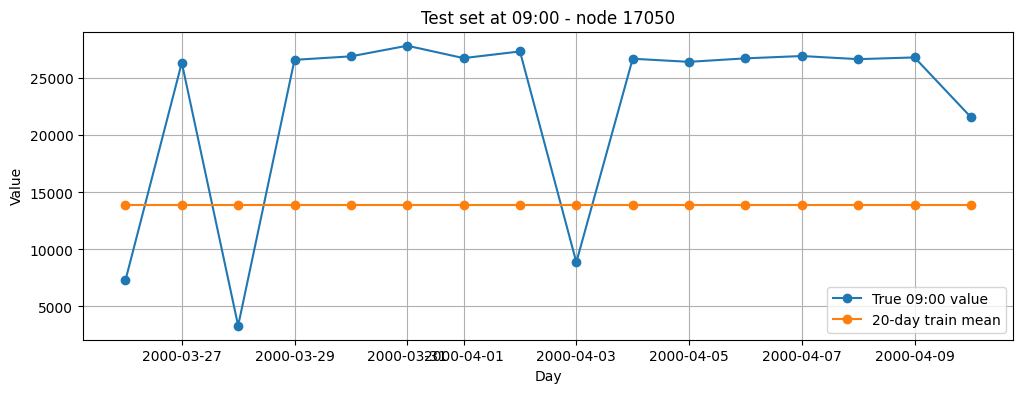

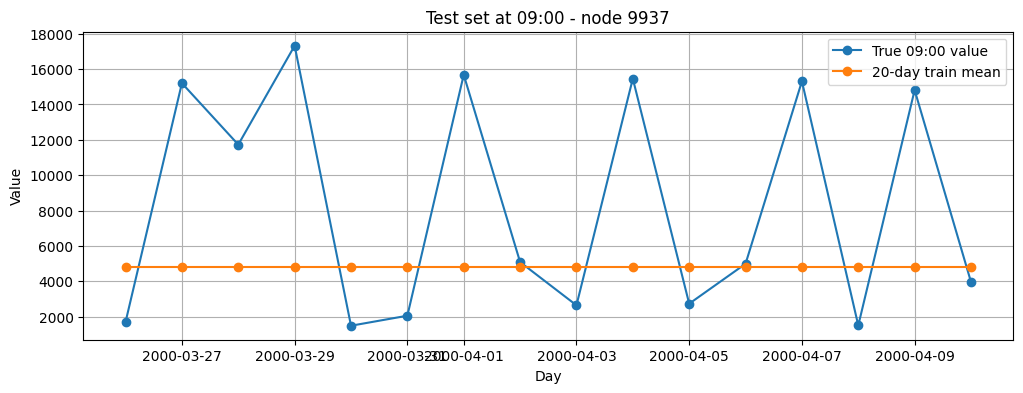

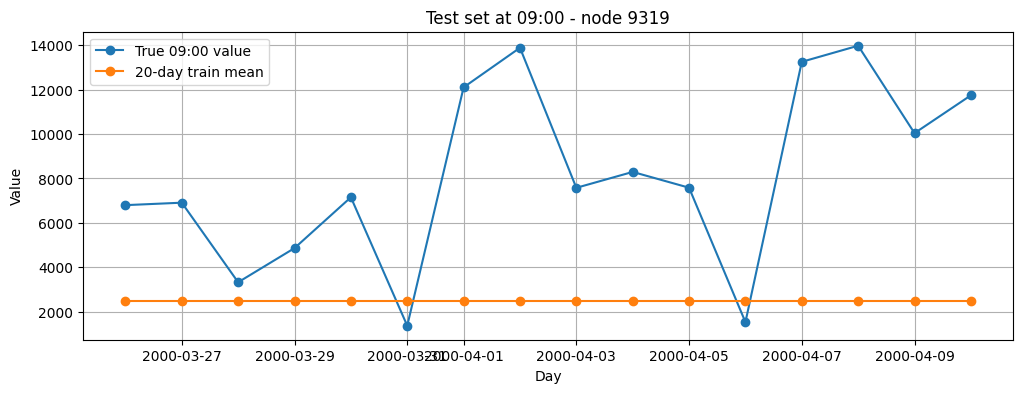

In [11]:
# Plot the 3 worst nodes on the test split
worst_nodes = test_node_metrics["node"].head(3).tolist()

for node in worst_nodes:
    plt.figure(figsize=(12, 4))
    plt.plot(test_df.index, test_df[node], marker="o", label="True 09:00 value")
    plt.plot(test_pred.index, test_pred[node], marker="o", label="20-day train mean")
    plt.title(f"Test set at 09:00 - node {node}")
    plt.xlabel("Day")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()

In [1]:
from pathlib import Path
import pickle
import networkx as nx
import pandas as pd

GRAPH_SPECTRUM_DIR = Path(
    r"C:\Users\USER\Documents\GitHub\Traffic-Congestion-Estimation-on-Graphs-via-GP\outputs\graph_spectrum"
)

GRAPH_PATH = GRAPH_SPECTRUM_DIR / "canonical_graph.gpickle"
NODE_TO_INDEX_PATH = GRAPH_SPECTRUM_DIR / "node_to_index.json"

# Load graph
with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

# Optional: only keep nodes present in spectral mapping
import json

with open(NODE_TO_INDEX_PATH, "r") as f:
    node_to_pos = {int(k): int(v) for k, v in json.load(f).items()}

mapped_nodes = set(node_to_pos.keys())

rows = []

for node, degree in G.degree():
    node = int(node)

    if node not in mapped_nodes:
        continue

    # Radius-5 neighborhood size
    radius_nodes = nx.single_source_shortest_path_length(
        G,
        node,
        cutoff=5,
    )

    radius_nodes = [
        int(n)
        for n in radius_nodes.keys()
        if int(n) in mapped_nodes
    ]

    rows.append({
        "node": node,
        "degree": int(degree),
        "radius_5_nodes": len(radius_nodes),
    })

degree_df = pd.DataFrame(rows)

degree_df = degree_df.sort_values(
    ["degree", "radius_5_nodes"],
    ascending=False,
).reset_index(drop=True)

display(degree_df.head(30))

Graph nodes: 1570
Graph edges: 2803


,node,degree,radius_5_nodes
0,8276,7,134
1,9808,7,127
2,9576,7,107
3,13226,7,99
4,10068,6,137
5,9481,6,136
6,9802,6,131
7,10131,6,131
8,1025,6,130
9,10171,6,129
